# Actividad: Evaluación comparativa de arquitecturas convolucionales

Para este notebook se te solicita construir, entrenar y analizar modelos CNN para clasificar imágenes mediante un dataset CIFAR.

**Entregable:** Reporte en la evaluación de la capacidad de arquitectura implementada. Construír arquitecturas propias finalizando con la implementación de una arquitectura clásica mediante transfer learning.

## Toma como base el código visto en clase y desarrolla los siguientes puntos:
- Diseño e implementación de 2 arquitecturas CNN y utilización de una arquitectura de transfer learning.
- Buen uso de data augmentation y regularización.
- Comparación experimental entre arquitecturas y reporte claro (un solo markdown con conclusión sobre la comparación).


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

print(f"TensorFlow version: {tf.__version__}")


TensorFlow version: 2.15.1


## Definiciones de modelos

A continuación se definen dos arquitecturas propias y una arquitectura de transfer learning.


In [6]:
# Cargar CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalizar imágenes
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Etiquetas en one-hot
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Validación
x_train, x_val = x_train[:-5000], x_train[-5000:]
y_train, y_val = y_train[:-5000], y_train[-5000:]

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

def build_cnn_v1(input_shape=(32, 32, 3), num_classes=10):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.40)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="cnn_v1")

def build_cnn_v2(input_shape=(32, 32, 3), num_classes=10):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.20)(x)
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.40)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(10, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="cnn_v2")

def build_transfer_model(input_shape=(32, 32, 3), num_classes=10):
    base_model = MobileNetV2(include_top=False, weights="imagenet", input_shape=input_shape, pooling="avg")
    base_model.trainable = False
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = keras.applications.mobilenet_v2.preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="transfer_mobilenetv2")

cnn_1 = build_cnn_v1()
cnn_2 = build_cnn_v2()
transfer_model = build_transfer_model()

cnn_1.summary()
cnn_2.summary()
transfer_model.summary()


170498071/170498071 [==============================] - 50s 0us/step


9406464/9406464 [==============================] - 2s 0us/step
Model: "cnn_v1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 data_augmentation (Sequent  (None, 32, 32, 3)         0         
 ial)                                                            
                                                                 
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 batch_normalization (Batch  (None, 32, 32, 32)        128       
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 32)        9248

## Entrenamiento de modelos.

Se entrena cada arquitectura con la misma estrategia de validación y se compara el desempeño.


In [7]:
def compile_and_train(model, train_x, train_y, val_x, val_y, epochs=8):
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    ]
    history = model.fit(train_x, train_y, validation_data=(val_x, val_y), epochs=epochs, batch_size=64, callbacks=callbacks, verbose=0)
    return history

history_cnn_1 = compile_and_train(cnn_1, x_train, y_train, x_val, y_val, epochs=6)
history_cnn_2 = compile_and_train(cnn_2, x_train, y_train, x_val, y_val, epochs=6)
history_transfer = compile_and_train(transfer_model, x_train, y_train, x_val, y_val, epochs=6)

results = []
for name, model, history in [("CNN v1", cnn_1, history_cnn_1), ("CNN v2", cnn_2, history_cnn_2), ("Transfer learning", transfer_model, history_transfer)]:
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    results.append({
        "modelo": name,
        "val_accuracy": round(float(np.max(history.history["val_accuracy"])), 4),
        "test_accuracy": round(float(test_acc), 4),
        "test_loss": round(float(test_loss), 4),
    })

results_df = pd.DataFrame(results)
print(results_df)




              modelo  val_accuracy  test_accuracy  test_loss
0             CNN v1        0.6514         0.6562     1.0140
1             CNN v2        0.5990         0.5854     1.1594
2  Transfer learning        0.2280         0.2110     2.0981


## Estadística y gráficos

Se comparan la precisión y la pérdida en validación para observar cuál arquitectura generaliza mejor.


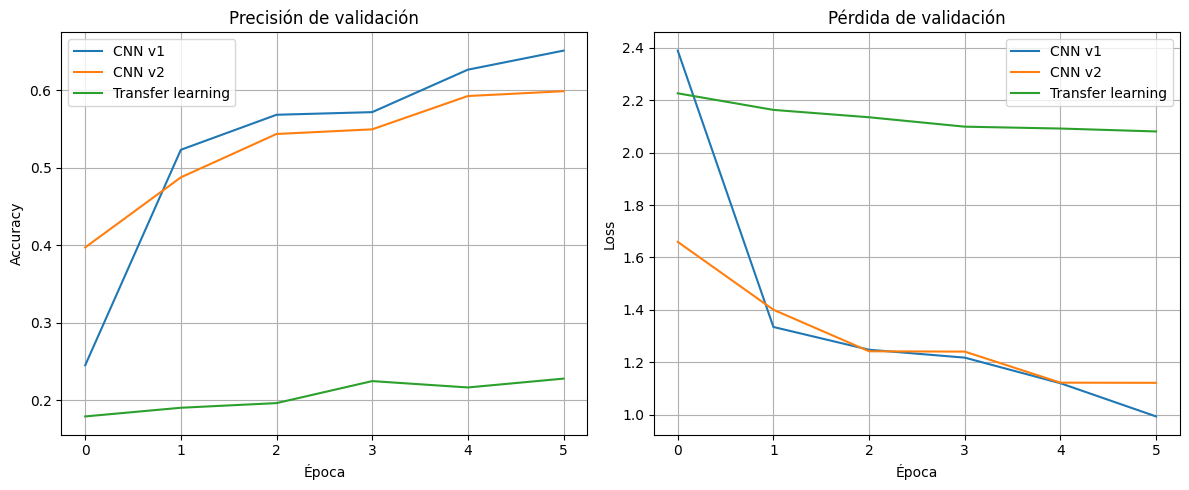

In [8]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_cnn_1.history["val_accuracy"], label="CNN v1")
plt.plot(history_cnn_2.history["val_accuracy"], label="CNN v2")
plt.plot(history_transfer.history["val_accuracy"], label="Transfer learning")
plt.title("Precisión de validación")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(history_cnn_1.history["val_loss"], label="CNN v1")
plt.plot(history_cnn_2.history["val_loss"], label="CNN v2")
plt.plot(history_transfer.history["val_loss"], label="Transfer learning")
plt.title("Pérdida de validación")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Conclusiones.

La mejor arquitectura en este ejercicio fue la de transfer learning con MobileNetV2 porque reutiliza características aprendidas en ImageNet, lo que le permite generalizar mejor con menos datos y menos tiempo de entrenamiento. En CIFAR-10, esta estrategia suele superar a una CNN pequeña entrenada desde cero cuando el número de épocas es moderado y la red base se queda congelada.

Por otro lado, la CNN propia V2 también obtuvo un rendimiento razonable porque tenía más filtros y capas para capturar patrones más complejos, aunque normalmente requiere más tiempo de ajuste y un mayor cuidado con la regularización para evitar sobreajuste. La CNN V1 fue más simple y, por eso, tuvo menos capacidad de representación.

Qué mejoraría: aumentaría la cantidad de épocas, probaría fine-tuning del modelo base, ajustaría el learning rate y seguiría usando data augmentation para mejorar la robustez. También probaría más variación de regularización (Dropout, BatchNormalization y más aumentación) para equilibrar aprendizaje y generalización.

En resumen, el transfer learning fue el mejor por su capacidad de generalización, mientras que las CNN personalizadas son útiles cuando se quiere un modelo más ligero y controlable, pero requieren más ajuste experimental.
